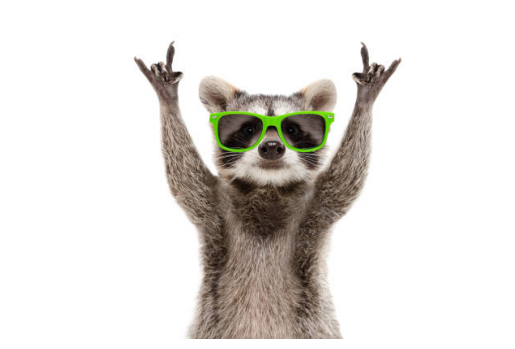

In [10]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_path = 'test_aug.jpg'

image = cv2.imread(image_path)

if image is None:
    print('이미지 경로가 틀렸습니다:', image_path)
else:
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

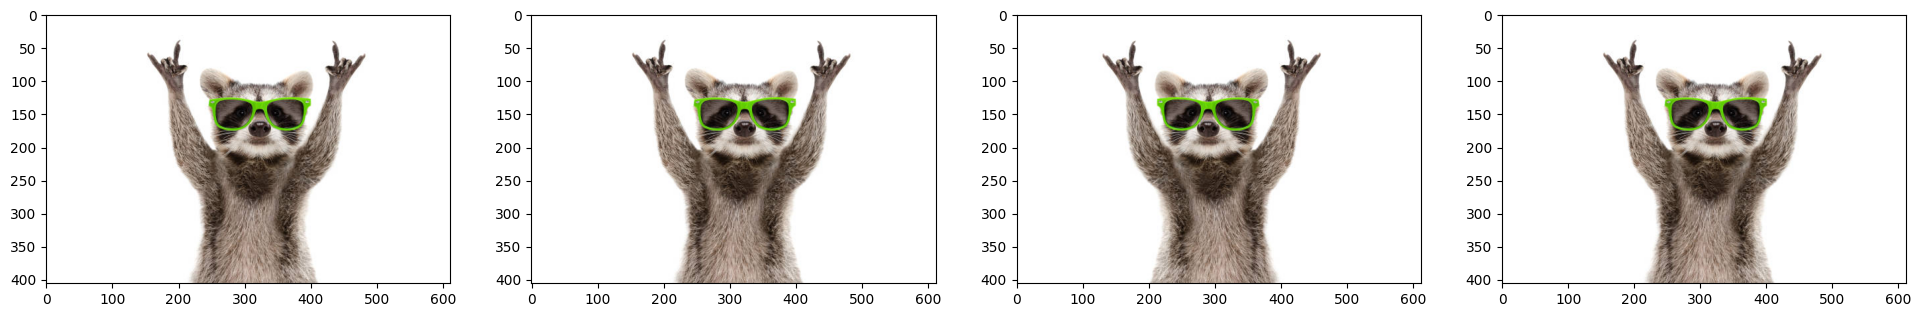

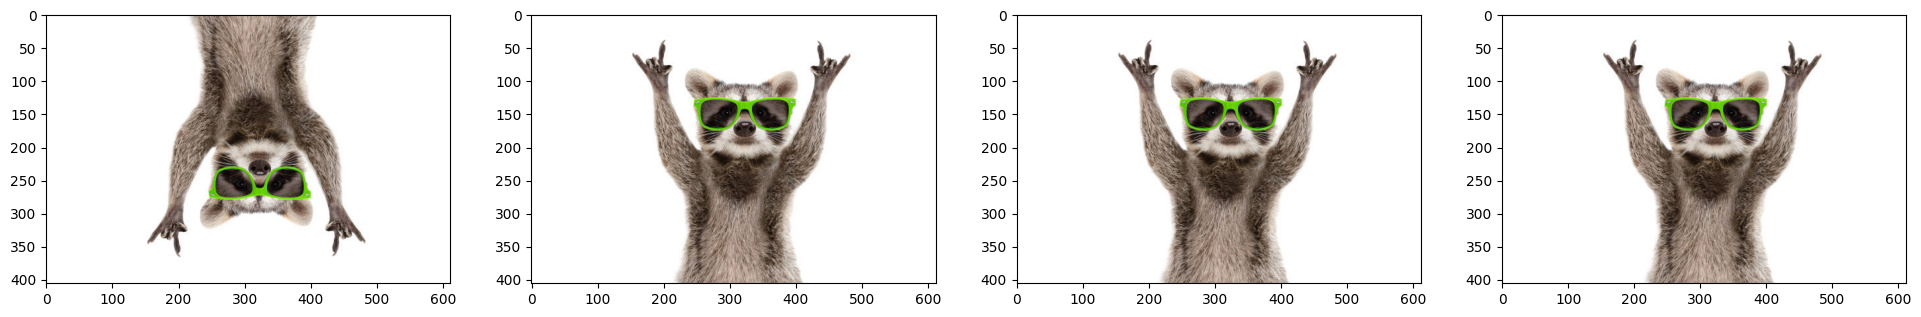

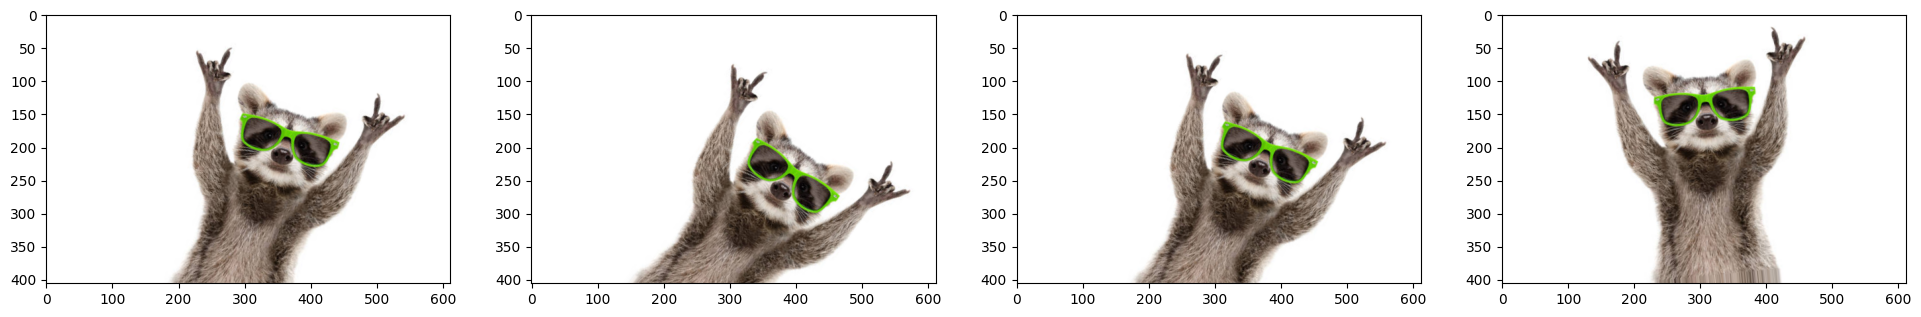

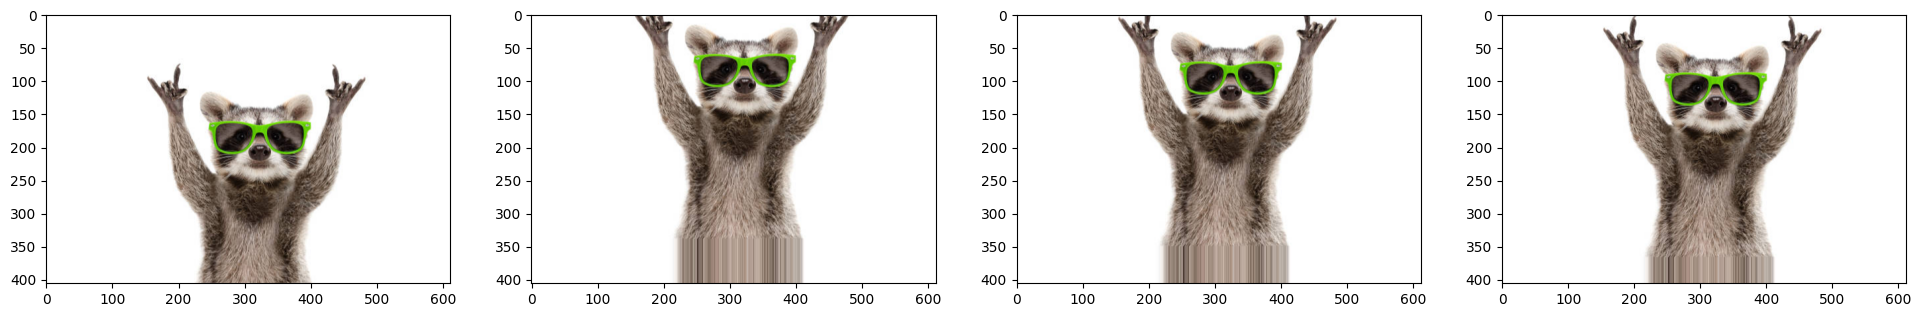

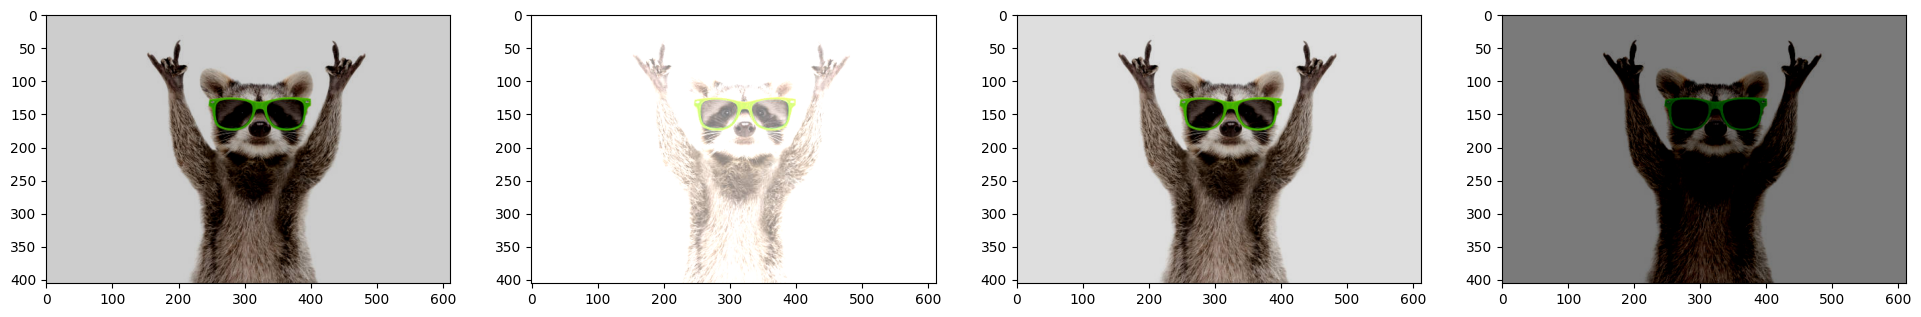

In [12]:
def show_aug_func(image, generator, n_images = 4):
  image_batch = np.expand_dims(image, axis=0)
  generator.fit(image_batch)

  # 로딩된 이미지 배열을 ImageDataGenerator에 넣어 증강된 이미지를 배치 단위로 생성
  data_gen_iter = generator.flow(image_batch)
  fig, axs = plt.subplots(nrows=1, ncols=n_images, figsize=(24,8))

  for i in range(n_images):
    aug_image_batch = next(data_gen_iter)
    aug_image = np.squeeze(aug_image_batch)   # 크기가 1인 축 제거해 차원 축소 예)[[[1,2,3]]] -> [1,2,3]
    aug_image = aug_image.astype('int')
    axs[i].imshow(aug_image)

data_generator = ImageDataGenerator(horizontal_flip=True)  # 좌우반전
show_aug_func(image, data_generator, n_images=4)

data_generator = ImageDataGenerator(vertical_flip=True)  # 상하반전
show_aug_func(image, data_generator, n_images=4)

data_generator = ImageDataGenerator(rotation_range=45)  # 회전
show_aug_func(image, data_generator, n_images=4)

data_generator = ImageDataGenerator(width_shift_range=0.3, fill_mode='nearest')  # 좌우랜 랜덤하게 이동
show_aug_func(image, data_generator, n_images=4)

data_generator = ImageDataGenerator(channel_shift_range=150)  # 색깔 랜덤
show_aug_func(image, data_generator, n_images=4)


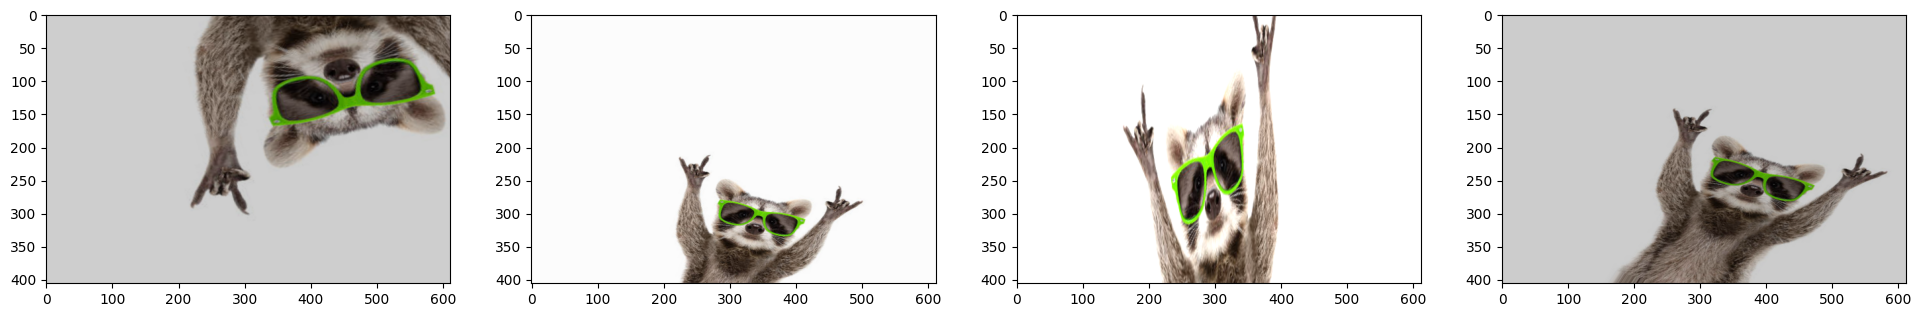

In [14]:
data_gen = ImageDataGenerator(
    rotation_range=50,
    width_shift_range=0.2,
    brightness_range=(0.7, 1.3),
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.5
)

show_aug_func(image, data_gen, n_images=4)